<a href="https://colab.research.google.com/github/Hunain513/week-1-ds-assignment/blob/main/assignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

TASK 1 - DATA PREPARATION

In [ ]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
pd.set_option("display.max_columns", None)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"] = df["TotalCharges"].astype(float)

In [ ]:
print(df["TotalCharges"].isnull().sum())

11


In [ ]:
df["TotalCharges"]= df["TotalCharges"].fillna(df["TotalCharges"].median())

In [ ]:
print(df["TotalCharges"].isnull().sum())

0


I have first convert any blank value with Nan so that dataset can be trained smoothly and also i have convert every value in the column to a floating point number so that it wont cause any error.

In [ ]:
df = df.drop(columns=["customerID"])

In [ ]:
print(df.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


As you can see , I have dropped the Customer ID column because it is just a unique label and not a necessary feature , it will just create noise.

In [ ]:
df["Churn"].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
df["Churn"].isnull().sum()

np.int64(0)

As you can see by this code , there is no missing values in Churn Column.

In [ ]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

This means that 5174 customers are old and didnt move from the company and 1869 customers are moved from the company.

In [ ]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

73 percent of the employeers stays in the company and 26 percent of them moved due to their circumstances.

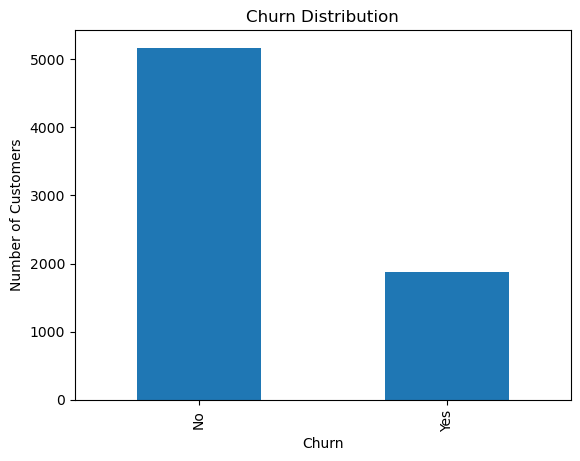

In [ ]:
df["Churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

This bar graph also shows that most of the employeers stays with the company, due to this dataset is imblanced because there are many more No cases than Yes cases. So during model training we need techniques like Oversampling to handle class imbalance.

TASK 2 - FEATURE ENGINEERING

For the next task , we have to ensure one hot encoding because our dataset contains text and machine learning algorithms cannot directly work with strings like Male or Yes. First let us identify columns.

In [ ]:
df.select_dtypes(include="object").columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [ ]:
df = pd.get_dummies(df, columns=["InternetService","PaymentMethod","MultipleLines"], drop_first=True)

In [ ]:
print(df.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'MultipleLines_No phone service', 'MultipleLines_Yes']


As you can see , after one hot encoding , we created a dummy columns by the command pd.get_dummies() and columns are increased . There are different categories so that one hot encoding avoids this problem by using seperate 0/1 columns. For the rest of the columns , we will use Binary variables as they can easily be mapped to 0 and 1.

In [ ]:
binary_cols = ["gender","Partner","Dependents","PhoneService","PaperlessBilling","Churn"]
for col in binary_cols:
    if col == "gender":
        df[col] = df[col].map({"Female":0, "Male":1})
    else:
        df[col] = df[col].map({"No":0, "Yes":1})

In [ ]:
print(df["gender"].head(10))

0    0
1    1
2    1
3    1
4    0
5    0
6    1
7    0
8    0
9    1
Name: gender, dtype: int64


For the categorical variables were encoded before model training. Binary categorical features (e.g., Partner, Dependents, and Churn) were converted into 0/1 values using label mapping. Nominal variables with more than two categories (e.g., InternetService, Contract, and PaymentMethod) were transformed using one-hot encoding to avoid introducing an artificial order.

Feature 1 - High Monthly Charge Customer

For the next task , we have to engineered three new features for this dataset , as this dataset is related to customer support , i think we should focus on customers , for this point , we can have features as Premium Customer , mean thats customers that have higher monthly bills and they are more sensitive to prices increase and they are more likely to left company. This feature is beneficial as we can seperate customers that are paying high to the company.

In [ ]:
df["HighMonthlyCharge"] = (df["MonthlyCharges"] > 70).astype(int)

In [ ]:
print(df[["MonthlyCharges", "HighMonthlyCharge"]].head(10))

   MonthlyCharges  HighMonthlyCharge
0           29.85                  0
1           56.95                  0
2           53.85                  0
3           42.30                  0
4           70.70                  1
5           99.65                  1
6           89.10                  1
7           29.75                  0
8          104.80                  1
9           56.15                  0


This code will count how many customers are in each group.

In [ ]:
print(df["HighMonthlyCharge"].value_counts())

HighMonthlyCharge
1    3583
0    3460
Name: count, dtype: int64


I created this HighMonthlyCharge feature by classifying customers with monthly charges above 70 as high paying customers, This way we can differentiate customers with higher bills.

Feature 2 - Long- Term Contract Customer

In [ ]:
df["LongTermContract"] = (df["Contract"] != "Month-to-month").astype(int)

In [ ]:
print(df[["Contract", "LongTermContract"]].head(10))

         Contract  LongTermContract
0  Month-to-month                 0
1        One year                 1
2  Month-to-month                 0
3        One year                 1
4  Month-to-month                 0
5  Month-to-month                 0
6  Month-to-month                 0
7  Month-to-month                 0
8  Month-to-month                 0
9        One year                 1


This new features introduce customers that have a larger contract of one year , because it will guide us about our old customers and those long term contracts customers are generally more committed to the service and they are less likely to leave this company.

Feature 3 Online Service User

In [ ]:
online_services = ["OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]

df["UsesOnlineServices"] = (
    (df[online_services] == "Yes").sum(axis=1) > 0
).astype(int)

In [ ]:
print(df[["UsesOnlineServices"]].head())
print(df["UsesOnlineServices"].value_counts())

   UsesOnlineServices
0                   1
1                   1
2                   1
3                   1
4                   0
UsesOnlineServices
1    4824
0    2219
Name: count, dtype: int64


There are customers who subscribe to one or more online services may be more alligned with company and which could influence their likelihood of a remaining a customer.

TASK 3 - Feature Scaling

We have to identify which of these features require scaling and which of them are not .

Since we can only scale numerical feature , So MonthlyCharges , TotalCharges , AvgMonthlySpend, and Tenure have numerical values so we can scale them . Gender , Partner , Dependants and Phone Services cannot be scaled as they are already in binary 0/1 or dummy variables.

For the second requirement , you need to apply two different scaling techniques to the numerical features only . For this I will use Monthly Charges ,Tenure and Total Charges, we can scale them.

In [ ]:
scale_cols = ["tenure", "MonthlyCharges","TotalCharges"]

Now we will train- test split our data before applying scaling techniques.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Churn"],axis=1)
y = df["Churn"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

Now After Train-test Split , we will apply StandardScaler.


In [ ]:
from sklearn.preprocessing import StandardScaler

scale_cols= ["tenure", "MonthlyCharges","TotalCharges"]
scaler = StandardScaler()

X_train_std = X_train.copy()
X_test_std = X_test.copy()

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

In [ ]:
print(X_train_std[scale_cols].head())

      tenure  MonthlyCharges  TotalCharges
3738      35           49.20       1701.65
3151      15           75.10       1151.55
4860      13           40.55        590.35
3867      26           73.50       1905.70
3810       1           44.55         44.55


These values are centered around 0.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

X_train_minmax = X_train.copy()
X_test_minmax = X_test.copy()

X_train_minmax[scale_cols] = minmax_scaler.fit_transform(X_train[scale_cols])
X_test_minmax[scale_cols] = minmax_scaler.transform(X_test[scale_cols])


In [ ]:
print(X_train_minmax[scale_cols].head())

        tenure  MonthlyCharges  TotalCharges
3738  0.486111        0.306926      0.194185
3151  0.208333        0.565022      0.130707
4860  0.180556        0.220727      0.065948
3867  0.361111        0.549078      0.217731
3810  0.013889        0.260588      0.002966


These all values are between 0 and 1.

As stated Fit your scaler only on the training set and apply it to the test set , The scaler was fitted only on the training set using fit_transform() and then we apply the test using transform(). We can avoid data leakage from this and keeping test data unseen can ensure model been trained justly.

Which Scaling Technique was carried forward?

I am using support vector machine as a scaling technique because both Standard Scaler and Min Max Scaler were applied to the numerical features. For standardscaler , it standardizes features to have a mean zero and and standard deviation of one . so this method generally improves the optimization , thats why i have used support vector machine.

Task 4 - Model Building

Split the data into training and test sets state your split ratio and whether you stratified on the target.


In [ ]:
# For Features and Target Variables
# Churn is the target variable, and the rest of the columns are features.

X=df.drop(columns=["Churn"],axis=1)
y=df["Churn"]

#Split the dataset into training and testing sets.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



In [ ]:
print("Traning set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Traning set size: 5634
Testing set size: 1409


Checking the class distribution of your target variable Churn , if they are same , we are going for model training.

In [ ]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


Now the dataset was split into 80 percent training data and 20 percent testing data and we ensure that both churned and non-churned are almost the same in both training and testing sets.

Trained atleast four classification algorithms on the prepared dataset. First we train this dataset on Logistic Regression.

1. Logistic Regression

In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
# Tranining

LR = LogisticRegression(max_iter=1000, random_state=42)
LR.fit(X_train, y_train)

#Prediction

y_pred = LR.predict(X_test)
y_prob = LR.predict_proba(X_test)[:,1]

#Evaluation


print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

Accuracy: 0.8041163946061036
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.74      1409
weighted avg       0.80      0.80      0.80      1409

Confusion Matrix:
[[926 109]
 [167 207]]
ROC AUC Score: 0.842240822547728


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
print(df.select_dtypes(include="object").columns)

Index(['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract'],
      dtype='object')


These are the columns that still have yes no so we have to do one - hot encoding on them.

In [ ]:
df = pd.get_dummies(df, columns=["Contract"], drop_first=True)

for col in ["OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]:
    print(col)
    print(df[col].unique())
    print()

OnlineSecurity
['No' 'Yes' 'No internet service']

OnlineBackup
['Yes' 'No' 'No internet service']

DeviceProtection
['No' 'Yes' 'No internet service']

TechSupport
['No' 'Yes' 'No internet service']

StreamingTV
['No' 'Yes' 'No internet service']

StreamingMovies
['No' 'Yes' 'No internet service']



In [ ]:
df = pd.get_dummies(
    df,
    columns=[
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies"
    ],
    drop_first=True
)

In [ ]:
print(df.select_dtypes(include="object").columns)

Index([], dtype='object')


Now we dont have any string value , and from the table we got 80 percent accuracy using logistic regression. This shows after handling class imbalance , this model shows 80 percent of accuracy.

2. K Nearest Neighbours (KNN)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Training
knn = KNeighborsClassifier(n_neighbors=25)
knn.fit(X_train, y_train)

# Prediction
y_pred = knn.predict(X_test)
y_prob = knn.predict_proba(X_test)[:,1]

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

Accuracy: 0.7899219304471257
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.94      0.87      1035
           1       0.69      0.38      0.49       374

    accuracy                           0.79      1409
   macro avg       0.75      0.66      0.68      1409
weighted avg       0.78      0.79      0.77      1409

Confusion Matrix:
[[970  65]
 [231 143]]
ROC AUC Score: 0.8015384019220337


KNN measures the distance between data points, if one feature has a much larger range than another , it can dominate the distance calculation. lets change the k value , i am getting 75 percent accuracy k = 5 and i put k = 25 and i got 80 percent accuracy , and that is the maximum accuracy i am getting after changing the value of k.

In [ ]:
df = pd.get_dummies(
    df,
    columns=[
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies",
        "Contract"
    ],
    drop_first=True
)

In [ ]:
print(X_train.shape)
print(X_test_std.shape)

print(X_train.columns.equals(X_test_std.columns))

(5634, 26)
(1409, 26)
True


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.preprocessing import StandardScaler

# Numerical columns only
scale_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

# Create copies
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Create scaler
scaler = StandardScaler()

# Scale only numerical columns
X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])

X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

In [ ]:
print(X_train_scaled.head())
print(X_test_scaled.head())

      gender  SeniorCitizen  Partner  Dependents    tenure  PhoneService  \
3738       1              0        0           0  0.102371             0   
3151       1              0        1           1 -0.711743             1   
4860       1              0        1           1 -0.793155             0   
3867       0              0        1           0 -0.263980             1   
3810       1              0        1           1 -1.281624             1   

      PaperlessBilling  MonthlyCharges  TotalCharges  \
3738                 0       -0.521976     -0.263289   
3151                 0        0.337478     -0.504814   
4860                 0       -0.809013     -0.751213   
3867                 1        0.284384     -0.173699   
3810                 0       -0.676279     -0.990851   

      InternetService_Fiber optic  InternetService_No  \
3738                        False               False   
3151                         True               False   
4860                        False  

In [ ]:
print(df.dtypes)

gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
InternetService_Fiber optic                 bool
InternetService_No                          bool
PaymentMethod_Credit card (automatic)       bool
PaymentMethod_Electronic check              bool
PaymentMethod_Mailed check                  bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
HighMonthlyCharge                          int64
LongTermContract                           int64
UsesOnlineServices                         int64
OnlineSecurity_No in

In [ ]:
from sklearn.svm import SVC
# Create the SVM model
svm = SVC(random_state=42, probability=True)

# Train the model on the scaled training data
svm.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred_svm = svm.predict(X_test_scaled)

# Predict probabilities for ROC-AUC
y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob_svm))

Accuracy: 0.7934705464868701

Confusion Matrix:
[[935 100]
 [191 183]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1035
           1       0.65      0.49      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409


ROC-AUC Score: 0.7946859903381643


The Support Vector Machine (SVM) classifier achieved an accuracy of 79  on the test dataset. This indicates that the model correctly classified approximately 79% of the customer churn instances. Since SVM is a distance-based algorithm, it was trained using the StandardScaler transformed features to ensure that all numerical variables contributed equally to the decision boundary.


4. Naives Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

# Create the Naive Bayes model
nb = GaussianNB()

# Train the model
nb.fit(X_train_scaled, y_train)

# Make predictions
y_pred_nb = nb.predict(X_test_scaled)

# Predict probabilities
y_prob_nb = nb.predict_proba(X_test_scaled)[:, 1]

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred_nb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob_nb))

Accuracy: 0.6841731724627396

Confusion Matrix:
[[647 388]
 [ 57 317]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.63      0.74      1035
           1       0.45      0.85      0.59       374

    accuracy                           0.68      1409
   macro avg       0.68      0.74      0.67      1409
weighted avg       0.79      0.68      0.70      1409


ROC-AUC Score: 0.8083288124208842


The Gaussian Naive Bayes classifier achieved an accuracy of 68 on the test dataset. Its performance was lower than the other models because Naive Bayes assumes that all features are independent of one another, an assumption that is not fully satisfied in the customer churn dataset. As a result, the model was less effective at capturing the relationships between customer attributes, leading to lower predictive performance.


In [ ]:
# Create comparison table
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "K-Nearest Neighbors (K=25)",
        "Support Vector Machine (SVM)",
        "Gaussian Naive Bayes"
    ],
    "Scaling Required": [
        "Yes",
        "Yes",
        "Yes",
        "No"
    ],
    "Accuracy (%)": [
        79,
        80,
        79,
        68
    ]
})

# Display the table
print(comparison)

                          Model Scaling Required  Accuracy (%)
0           Logistic Regression              Yes            79
1    K-Nearest Neighbors (K=25)              Yes            80
2  Support Vector Machine (SVM)              Yes            79
3          Gaussian Naive Bayes               No            68
